In [2]:
import numpy as np
import scipy.integrate as integrate
import warnings
warnings.filterwarnings('ignore') # Suppress integration warnings

class HestonAnalytical:
    def _Pj(self, j, S0, K, T, r, kappa, theta, sigma, rho, v0):
        def integrand(u):
            i = 1j
            
            # Heston 1993 parameters for P1 and P2
            b_j = kappa - rho * sigma if j == 1 else kappa
            u_j = 0.5 if j == 1 else -0.5
            a = kappa * theta
            
            # Albrecher (2007) formulation for numerical stability
            d = np.sqrt((rho * sigma * i * u - b_j)**2 - sigma**2 * (2 * u_j * i * u - u**2))
            g = (b_j - rho * sigma * i * u + d) / (b_j - rho * sigma * i * u - d)
            
            C = r * i * u * T + (a / sigma**2) * (
                (b_j - rho * sigma * i * u + d) * T - 2 * np.log((1 - g * np.exp(d * T)) / (1 - g))
            )
            D = (b_j - rho * sigma * i * u + d) / sigma**2 * ((1 - np.exp(d * T)) / (1 - g * np.exp(d * T)))
            
            f = np.exp(C + D * v0 + i * u * np.log(S0))
            return (np.exp(-i * u * np.log(K)) * f / (i * u)).real
            
        # We start at 1e-4 to elegantly bypass the division-by-zero singularity at u=0
        integral, _ = integrate.quad(integrand, 1e-4, 100, limit=200)
        return 0.5 + (1.0 / np.pi) * integral

    def price_call(self, S0, K, T, r, kappa, theta, sigma, rho, v0):
        P1 = self._Pj(1, S0, K, T, r, kappa, theta, sigma, rho, v0)
        P2 = self._Pj(2, S0, K, T, r, kappa, theta, sigma, rho, v0)
        return S0 * P1 - K * np.exp(-r * T) * P2

# --- Test the engine ---
heston = HestonAnalytical()
price = heston.price_call(100.0, 100.0, 1.0, 0.05, 2.0, 0.04, 0.3, -0.7, 0.04)
print(f"Heston Model Option Price: ${price:.4f}")

Heston Model Option Price: $10.3941


In [3]:
import pandas as pd
from scipy.optimize import least_squares
import time

# 1. Load the market data
df = pd.read_csv('../data/spy_call_options.csv')

# 2. Select a single expiration date to calibrate (e.g., 30-90 days out)
# We sort expirations and pick one roughly in the middle for a clear Volatility Smile
unique_exps = sorted(df['expiration'].unique())
target_exp = unique_exps[len(unique_exps) // 4] 

df_calib = df[df['expiration'] == target_exp].copy()
print(f"Calibrating to SPY options expiring on: {target_exp}")
print(f"Number of contracts used: {len(df_calib)}")

# 3. Extract constant market variables
S0 = df_calib['S0'].iloc[0]
r = df_calib['r'].iloc[0]
tau = df_calib['tau'].iloc[0]
market_strikes = df_calib['strike'].values
market_prices = df_calib['mid_price'].values

# 4. Define the Objective Function for the Optimizer
def heston_error(params):
    kappa, theta, sigma, rho, v0 = params
    
    # Calculate model prices for every strike in the chain
    model_prices = [
        heston.price_call(S0, K, tau, r, kappa, theta, sigma, rho, v0)
        for K in market_strikes
    ]
    
    # Return the residuals (Model - Market)
    return np.array(model_prices) - market_prices

# 5. Set Initial Guesses and Parameter Bounds
# Order: [kappa, theta, sigma, rho, v0]
initial_guess = [2.0, 0.04, 0.3, -0.7, 0.04]

bounds = (
    [0.01, 0.001, 0.01, -0.99, 0.001], # Lower bounds
    [10.0, 0.500, 2.00,  0.99, 0.500]  # Upper bounds
)

# 6. Run the Optimizer
print("Starting Levenberg-Marquardt optimizer... (this may take 5-20 seconds)")
start_time = time.time()

result = least_squares(
    heston_error, 
    initial_guess, 
    bounds=bounds,
    method='trf', # Trust Region Reflective handles bounds well
    ftol=1e-5, 
    xtol=1e-5
)

# 7. Print the Results
print(f"\nCalibration Complete in {time.time() - start_time:.2f} seconds!")
print("--- Optimal Heston Parameters ---")
print(f"Kappa (Mean Reversion) : {result.x[0]:.4f}")
print(f"Theta (Long-term Var)  : {result.x[1]:.4f}")
print(f"Sigma (Vol of Vol)     : {result.x[2]:.4f}")
print(f"Rho (Correlation)      : {result.x[3]:.4f}")
print(f"v0 (Current Variance)  : {result.x[4]:.4f}")

Calibrating to SPY options expiring on: 2026-07-31
Number of contracts used: 223
Starting Levenberg-Marquardt optimizer... (this may take 5-20 seconds)

Calibration Complete in 74.29 seconds!
--- Optimal Heston Parameters ---
Kappa (Mean Reversion) : 5.9276
Theta (Long-term Var)  : 0.0321
Sigma (Vol of Vol)     : 0.8878
Rho (Correlation)      : -0.9900
v0 (Current Variance)  : 0.0304


Calculating Heston prices and inverting to Implied Volatility... (Takes ~10 seconds)


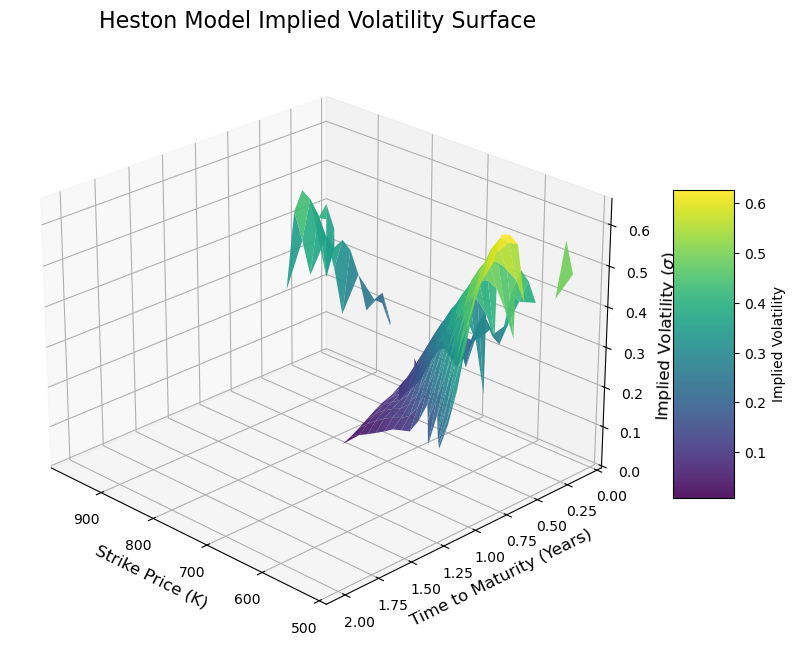

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.optimize import brentq
import warnings
warnings.filterwarnings("ignore")

# 1. Black-Scholes Implied Volatility Inverter
def bs_call_price(sigma, S, K, r, tau):
    """Calculates Black-Scholes price for a given volatility."""
    if tau <= 0: return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

def implied_volatility(price, S, K, r, tau):
    """Uses Brent's method to find the implied vol that matches the model price."""
    # If the price is below intrinsic value, it violates no-arbitrage bounds
    if price < max(S - K, 0): return np.nan 
    
    def objective_function(sigma):
        return bs_call_price(sigma, S, K, r, tau) - price
    
    try:
        # Search for a volatility between 1% and 300%
        return brentq(objective_function, 1e-4, 3.0)
    except ValueError:
        return np.nan

# 2. Extract your calibrated parameters
kappa_c, theta_c, sigma_c, rho_c, v0_c = result.x

# 3. Generate a 2D Grid of Strikes and Maturities
strikes = np.linspace(S0 * 0.7, S0 * 1.3, 30) # Strikes from 70% to 130% of Spot
maturities = np.linspace(0.1, 2.0, 30)        # Expirations from 1 month to 2 years

K_grid, T_grid = np.meshgrid(strikes, maturities)
IV_grid = np.zeros_like(K_grid)

print("Calculating Heston prices and inverting to Implied Volatility... (Takes ~10 seconds)")

# 4. Populate the Grid
for i in range(K_grid.shape[0]):
    for j in range(K_grid.shape[1]):
        K_target = K_grid[i, j]
        T_target = T_grid[i, j]
        
        # Get Heston Price
        heston_price = heston.price_call(S0, K_target, T_target, r, kappa_c, theta_c, sigma_c, rho_c, v0_c)
        
        # Convert to Implied Vol
        IV_grid[i, j] = implied_volatility(heston_price, S0, K_target, r, T_target)

# 5. Plot the 3D Volatility Surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(K_grid, T_grid, IV_grid, cmap='viridis', edgecolor='none', alpha=0.9)

# Formatting
ax.set_title('Heston Model Implied Volatility Surface', fontsize=16)
ax.set_xlabel('Strike Price (K)', fontsize=12)
ax.set_ylabel('Time to Maturity (Years)', fontsize=12)
ax.set_zlabel('Implied Volatility ($\sigma$)', fontsize=12)
ax.view_init(elev=25, azim=135) # Beautiful viewing angle
fig.colorbar(surf, shrink=0.5, aspect=5, label='Implied Volatility')

# Save the image to your repository
plt.savefig('../heston_vol_surface.png', dpi=300, bbox_inches='tight')
plt.show()